# **ACUTE LYMPHOBLASTIC LEUKEMIA CLASSIFIER**

**Developed by:** Marc Soria Ponseti  
**Field:** Biomedical Engineering/Medical AI  
**Accompanying Research Paper:** [Acute Lymphoblastic Leukemia Classifier PDF](https://drive.google.com/file/d/1znVgkDOlTgYLnItyDi0E2ZkqhS2W9EM2/view?usp=sharing)

#### **ABSTRACT & CONTEXT**

This project serves as an initial implementation of Deep Learning to classify blood smear images into **ALL (Malignant)** and **HEM (Healthy)**. Using a **ResNet50 backbone** through **transfer learning** and implementing custom **class-weighting** strategies to address class imbalance. The primary objective for this model was to improve **sensitivity**, a critical value in medical diagnostics to minimize false negatives. 

#### **REQUIREMENTS**

In [20]:
!pip install -q -U kagglehub tensorflow scikit-learn seaborn matplotlib pandas protobuf==3.20.3

In [21]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as tfl
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.layers import BatchNormalization, Conv2D, ReLU
from tensorflow.keras.applications.resnet50 import preprocess_input

## **DATASET**

**Dataset Source:** [C-NMC 2019 Leukemia Dataset (Kaggle)](https://www.kaggle.com/datasets/andrewmvd/leukemia-classification)

#### **DATA DOWNLOAD**

For this implementation, data was sourced exclusively from the `training_data` folder of the dataset, which is divided into three subsets. **Fold 0** and **Fold 1** were concatenated and shuffled to form the training set. **Fold 2** was split evenly (50/50) to create the validation and test sets.

In [22]:
path = kagglehub.dataset_download("andrewmvd/leukemia-classification")

In [23]:
base_path = os.path.join(path, "C-NMC_Leukemia", "training_data")
#-----------------------------------------------------------
#TRAINING

#Folders from training_data are downloaded in separate parts
ds0 = tf.keras.utils.image_dataset_from_directory(os.path.join(base_path, "fold_0"),
                                                  image_size = (224, 224),
                                                  batch_size = 32,
                                                  label_mode = 'binary')

ds1 = tf.keras.utils.image_dataset_from_directory(os.path.join(base_path, "fold_1"),
                                                  image_size = (224, 224),
                                                  batch_size = 32,
                                                  label_mode = 'binary')
print(ds0.class_names)

#folders 1 and 2 are grouped (concatenated) in one to create the training set
train_ds = ds0.concatenate(ds1)

#shuffle data to avoid bias due to the fact that the first 3000 imges could be ALL and the next 3000 HEM
train_ds = train_ds.shuffle(buffer_size=1000) 

#-----------------------------------------------------------
#VALIDATION
val_ds = tf.keras.utils.image_dataset_from_directory(os.path.join(base_path, "fold_2"),
                                                     image_size = (224, 224),
                                                     batch_size = 32,
                                                     label_mode = 'binary',
                                                     validation_split = 0.5, 
                                                     subset = "training",
                                                     seed = 123) # The seed ensures the split is identical every time
#-----------------------------------------------------------
#TESTING
test_ds = tf.keras.utils.image_dataset_from_directory(os.path.join(base_path, "fold_2"),
                                                      image_size = (224, 224),
                                                      batch_size = 32,
                                                      label_mode = 'binary',
                                                      validation_split = 0.5,
                                                      subset = "validation",
                                                      seed = 123)

Found 3527 files belonging to 2 classes.
Found 3581 files belonging to 2 classes.
['all', 'hem']
Found 3553 files belonging to 2 classes.
Using 1777 files for training.
Found 3553 files belonging to 2 classes.
Using 1776 files for validation.


I've optimized the data flow using `.cache()` and `.prefetch()`. This setup saves data in memory after the first epoch, it overlaps the data preprocessing of one epoch with the model execution of the previous one.

In [24]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

#### **VISUALIZING THE DATASET**

In this particular case, visualizing the data to see if labels are correct is not very useful unless you are an oncologist. Nevertheless, I thought that it would be important to show how similar cells from both classes are to highlight the complexity of this classification task.

In [25]:
def show_data():
    class_names = ds0.class_names 

    plt.figure(figsize=(8, 8))
    for images, labels in train_ds.take(1):
        for i in range(9):
            grid = plt.subplot(3, 3, i + 1) #to create a 3x3 grid
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[int(labels[i])].upper()) #add labels to images
            plt.tight_layout() #separation between images
            plt.axis("off")
    return

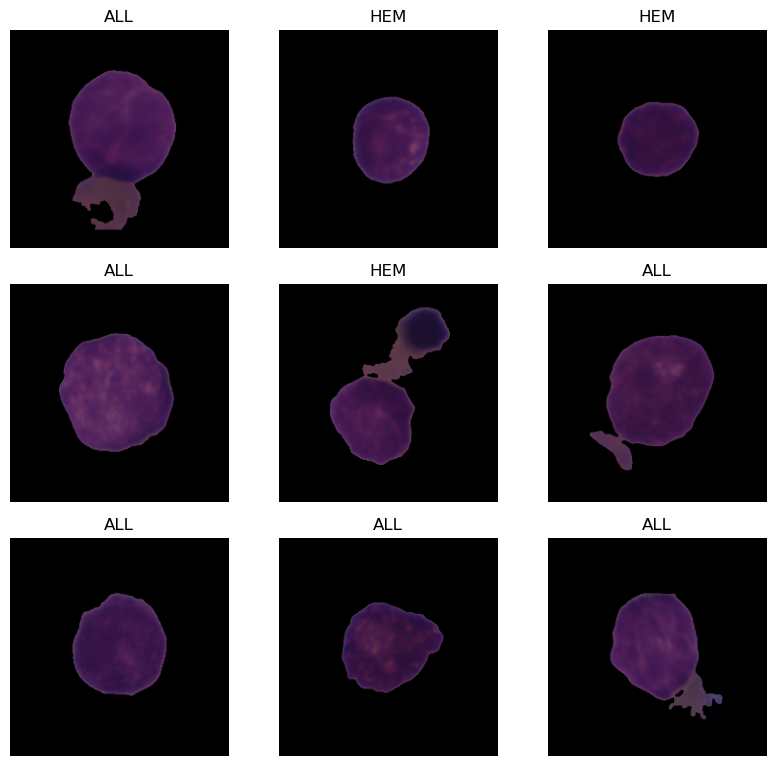

In [26]:
show_data()

#### **DATA AUGMENTATION**

I have artificially increased the diversity of the training set without collecting new data with **data augmentation**. Cells have no fixed orientation so to prevent overfitting I have implemented _random flips_, _ranodm rotations_ and _random zooms_.

In [27]:
def data_augmentation():
    """
    Creates a sequential model for data augmentation, preventing the model from overfitting.
    """
    
    data_augmentation = tf.keras.Sequential([tf.keras.layers.RandomFlip("horizontal_and_vertical"), #cells have no fixed orientation
                                        tf.keras.layers.RandomRotation(0.2), 
                                        tf.keras.layers.RandomZoom(0.2)])
    return data_augmentation

## **MODEL ARCHITECTURE**

This model has been built using **Transfer Learning** with a pre-trained **ResNet50** base trained with **ImageNet**. The top classification layers have been removed to implement my own layers focused on optimizing leukemia detection.

In [28]:
base_model = tf.keras.applications.ResNet50(
    weights = "imagenet",  #pre-trained weights
    include_top = False,   #top classification layer removed
    input_shape = (224, 224, 3))

**Functional API** has been used to create the final architecture. This model includes a **data augmentation** pipeline, **inputs preprocessing** for **ResNet50** and has a custom head composed of a **Global Average Pooling Layer**, a **Dropout Layer** to prevent overfitting and a final **Dense Layer** for classification with a **sigmoid** activation function.

In [29]:
def model(input_shape = (224, 224, 3)):
    
    data_aug = data_augmentation()
    #defining inputs
    inputs = tf.keras.Input(shape=input_shape)

    #data_augmentation of the inputs given
    x = data_aug(inputs, training = True)
    
    # data preprocessing using the same weights the model was trained on
    x = tf.keras.layers.Lambda(lambda img: tf.keras.applications.resnet50.preprocess_input(img))(inputs)
    
    # training = False to avoid keeping track of statistics in the batch norm layer
    x = base_model(x, training = False)
    
    #Global Average Pooling (Flatten layer would cause overfitting due to the little size of the dataset)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    
    #dropout with 40% chance of shutting down a neuron to prevent overfitting
    x = tf.keras.layers.Dropout(0.4)(x)
    
    #one neuron for binary classification, "sigmoid" activation function as it is binary classification too
    outputs = tf.keras.layers.Dense(1, activation = "sigmoid")(x)
    
    model = tf.keras.Model(inputs, outputs)

    return model

I created a first model which did not work as I expected first, because I wanted to change some parameters such as the Dropout rate, I had to build a third model `model_leukemia_classifier_v3`. Details and results on the first models can be found in **( posar el link del paper)**.

In [30]:
model_leukemia_classifier_v3 = model() 

## **TRAINING**

#### **PHASE 1 - FEATURE EXTRACTION**

In this stage of the training, the **ResNet50** pre-trained weights were frozen to preserve the learning it had made on **ImageNet**. Only the last layers I changed were trained here to adapt the architecture to the leukemia dataset.  
The code for training `.fit(...)` has been commented to save time to anyone running this cell (training could last hours in a laptop) and instead the models weights have been loaded.

In [31]:
base_model.trainable = False

#loading history
history_v3_phase1 = pd.read_csv("history_leukemia_classifier_v3.csv")

model_leukemia_classifier_v3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate= 0.001), 
              loss=tf.keras.losses.BinaryCrossentropy(from_logits = False), #as we used a sigmoid activation in the Dense layer before
              metrics=['accuracy', tf.keras.metrics.Recall(name = "sensitivity"),
                       tf.keras.metrics.AUC(name = "area_under_ROC_curve"),
                       tf.keras.metrics.Precision(name = "precision"),])

#-----------------------------------------------------------
#Early Stopping to prevent overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor ="val_loss", 
    patience = 5,             # so the model waits for 5 epoches before "giving up"
    restore_best_weights = True) #we want to keep the best version of the model, not the last one
#-----------------------------------------------------------

# Code for TRAINING 
# The model was trained for 10 epochs until convergence (which happened et epoch 6)
#history_v3 = model_leukemia_classifier_v3.fit(train_ds, validation_data=val_ds, epochs=10,
#                                                callbacks = [early_stop],
#                                                verbose = 1)     

#### **PHASE 2 - FINE-TUNING**

In this stage, all **ResNet50** layers were unfrozen to allow the entire network to adjust the weights for the specific task of leukemia detection. To make sure the pre-trained weights were being refined and not changed/overwritten, a $1 \times 10^{-5}$ learning rate was used.  
Also a **class imbalance** was detected, the **ALL : HEM** ratio was about **2.1 : 1**, this was affecting the model's sensitivity so personalized class weights were added.

In [ ]:
base_model.trainable = True

#loading history and weights of the model
history_v3_phase2 = pd.read_csv("history_leukemia_classifier_v3_finetuning.csv")
model_leukemia_classifier_v3.load_weights("model_leukemia_classifier_v3_finetuning.weights.h5")

model_leukemia_classifier_v3.compile(optimizer = tf.keras.optimizers.Adam(learning_rate= 1e-5), #we want small learning rate 
              loss= tf.keras.losses.BinaryCrossentropy(from_logits = False), #as we used a sigmoid activation in the Dense layer before
              metrics =["accuracy", tf.keras.metrics.Recall(name = "sensitivity"),
                       tf.keras.metrics.AUC(name = "area_under_ROC_curve"),
                       tf.keras.metrics.Precision(name ="precision"),])

#-----------------------------------------------------------
#Early Stopping to prevent overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = "val_loss", 
    patience = 8,             # so the model waits for 8 epoches before "giving up"
    restore_best_weights = True) #we want to keep the best version of the model, not the last one

#-----------------------------------------------------------
#Training Initialization 
#history_v3_finetuning = model_leukemia_classifier_v3.fit(train_ds, validation_data = val_ds, epochs = 40,
#    class_weight = {0: 2.5, 1: 1.0},                             #giving more importance to leukemic cells
#    callbacks = [early_stop],                                    #applying early stopping
#    verbose = 1)                                                 # to show progress bar

#### **VISUALIZING MODEL RESULTS**

The following function is used to plot the **accuracy** and **loss** for both the **training and validation** for the different epochs.

In [33]:
def plot_training_results(history):
    accuracy = history["accuracy"]
    val_accuracy = history["val_accuracy"]
    loss = history["loss"]
    val_loss = history["val_loss"]
    epochs_range = range(len(accuracy))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, accuracy, label = "Training Accuracy", marker = "o")
    plt.plot(epochs_range, val_accuracy, label = "Validation Accuracy", marker = "s")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(loc = "lower right")
    plt.grid(True)
   
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label = "Training Loss", marker= "o")
    plt.plot(epochs_range, val_loss, label = "Validation Loss", marker = "s")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(loc = "upper right")
    plt.grid(True)

    plt.tight_layout()
    plt.show()



In [34]:
model_leukemia_classifier_v3.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 23,536,641 (89.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

#### **PLOT FOR PHASE 1**

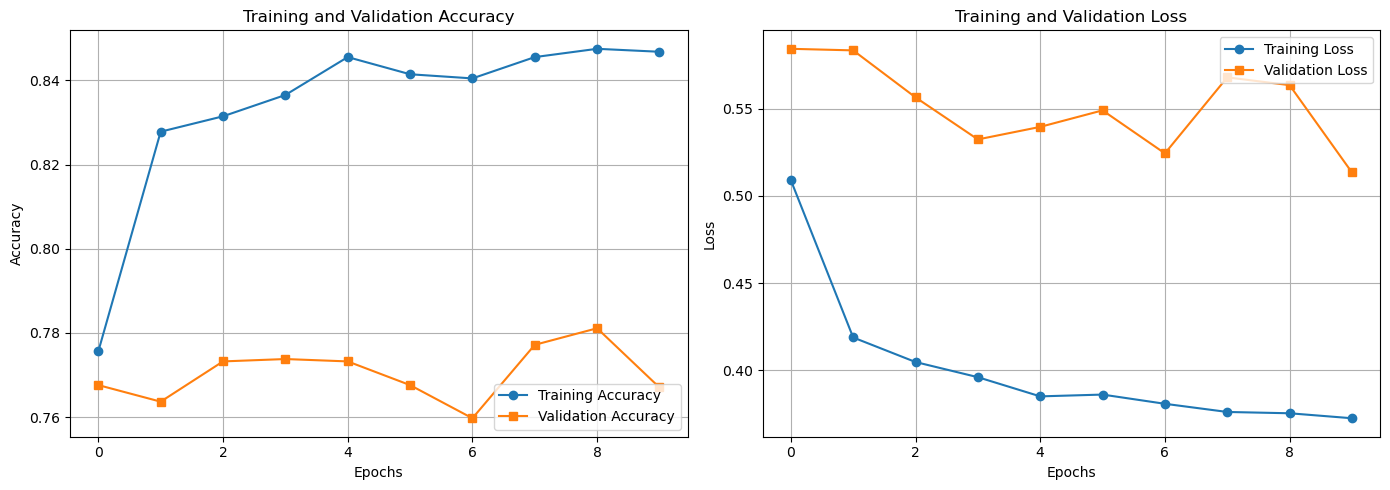

In [35]:
plot_training_results(history_v3_phase1)

#### **PLOT FOR PHASE 2**

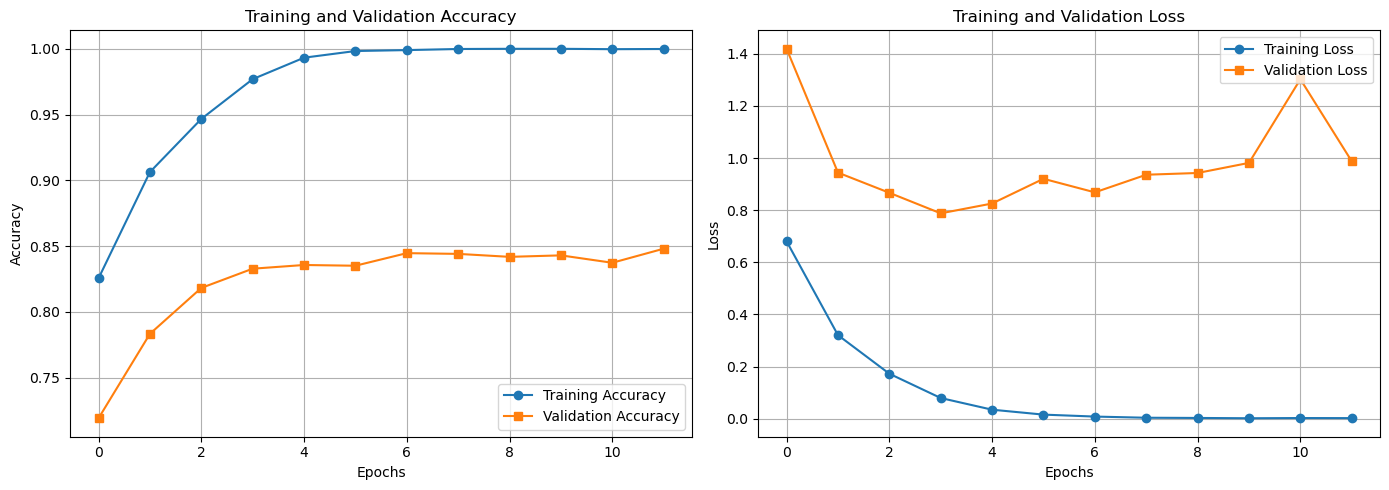

In [36]:
plot_training_results(history_v3_phase2)

## **FINAL MODEL EVALUATION**

To evaluate the model's ability to generalize it has to be evaluated on a unseen test set. With this it can be ensured that the model reflects true predictive metrics rather than data memorization from the training phase.

In [37]:
results = model_leukemia_classifier_v3.evaluate(test_ds)

#Match the results to their names
metrics_names = model_leukemia_classifier_v3.metrics_names
for name, value in zip(metrics_names, results):
    print(f"Test {name}: {value:.4f}") #to obtain fours decimal values

56/56 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.8328 - area_under_ROC_curve: 0.8324 - loss: 0.8289 - precision: 0.8504 - sensitivity: 0.5582
Test loss: 0.8289
Test compile_metrics: 0.8328


## **CONCLUSION & CONFUSION MATRIX**

The following code allows for a clear **visualization of the model's performance**, ploting a **confusion matrix** and a table with detailed results.

56/56 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step


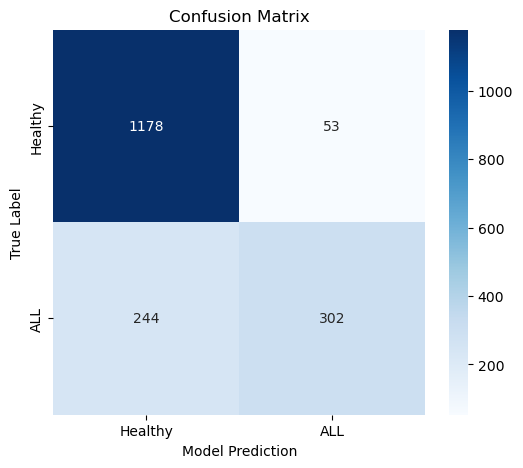

              precision    recall  f1-score   support

     Healthy       0.83      0.96      0.89      1231
         ALL       0.85      0.55      0.67       546

    accuracy                           0.83      1777
   macro avg       0.84      0.76      0.78      1777
weighted avg       0.84      0.83      0.82      1777



In [38]:
y_probs = model_leukemia_classifier_v3.predict(val_ds) 
y_pred = np.where(y_probs > 0.5, 1, 0) #conversion of probabilities to 0 and 1

y_true = np.concatenate([y for x, y in val_ds], axis=0) #true labels
#-----------------------------------------------------------
#Confusion matrix calculation
conf_mat = confusion_matrix(y_true, y_pred) #compares y_true with y_pred

#Confusion matrix plot
plt.figure(figsize = (6,5))
sns.heatmap(conf_mat, annot = True, fmt = "d", cmap = "Blues", 
            xticklabels = ["Healthy", "ALL"], 
            yticklabels =["Healthy","ALL"])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Model Prediction")
plt.show()
#-----------------------------------------------------------
#Detailed Table
print(classification_report(y_true, y_pred, target_names = ["Healthy", "ALL"]))

The final model achieved a final test **accuracy of 83.28%%** and an **AUC of 0.8324**, demonstrating a strong ability to distinguish between ALL and HEM cells. The model has a high **precision of 85.04%** which means that when it detects a leukemic cell it is most likely to be right. However, the **sensitivity value is 55.82%** meaning there are a lot of false negatives which in the medical field is unacceptable. Nevertheless, in a previous model built for this same task a 36% sensitivity value was obtained but the strategies documented in the attached paper allowed for a 19% improvement.
Even though this model is not yet ready to be used for real-world clinical use, I am proud of the progress made building, improving and documenting my first deep learning model.